In [96]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

In [97]:
def convert_to_rgb(image):
    img=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    return img

In [98]:
capture=cv2.VideoCapture('vtest.avi')

In [99]:
frame_get=capture.get(cv2.CAP_PROP_FRAME_HEIGHT)*np.random.uniform(size=30)

In [100]:
frame_get

array([151.91410398, 454.23487515, 509.03387965, 442.00963318,
       163.4276573 , 258.84304725, 423.14532147,  32.46874239,
        70.66094993, 251.627245  , 378.2661687 , 506.53607254,
       161.42338223, 174.01120314, 480.1031123 , 388.45102193,
        63.21326662,  39.03839234, 319.28403525, 198.64993429,
       151.76868103, 529.18112638,  81.53074985, 175.1753529 ,
       134.20132968, 255.09559579,   2.0712319 , 229.85843774,
       546.06482072, 487.7996999 ])

In [101]:
frames=[]

for i in frame_get:
    capture.set(cv2.CAP_PROP_POS_FRAMES,i)
    ret,frame=capture.read()
    frames.append(frame)
capture.release()

In [102]:
frames

[array([[[105, 143, 178],
         [106, 144, 179],
         [107, 145, 180],
         ...,
         [ 62,  92, 117],
         [ 75,  91, 118],
         [ 52,  68,  95]],
 
        [[106, 144, 179],
         [107, 145, 180],
         [108, 146, 181],
         ...,
         [ 54,  84, 109],
         [ 73,  89, 116],
         [ 55,  71,  98]],
 
        [[109, 147, 182],
         [109, 147, 182],
         [109, 147, 182],
         ...,
         [ 61,  88, 116],
         [ 76,  90, 116],
         [ 54,  68,  94]],
 
        ...,
 
        [[  0,  30,  18],
         [  0,  32,  20],
         [  0,  34,  22],
         ...,
         [ 14,  71,  57],
         [ 19,  72,  57],
         [ 19,  72,  57]],
 
        [[  0,  31,  19],
         [  0,  33,  21],
         [  0,  35,  23],
         ...,
         [ 10,  67,  53],
         [ 14,  68,  55],
         [ 17,  71,  58]],
 
        [[  0,  32,  20],
         [  0,  34,  22],
         [  0,  37,  25],
         ...,
         [ 14,  71,  57],
  

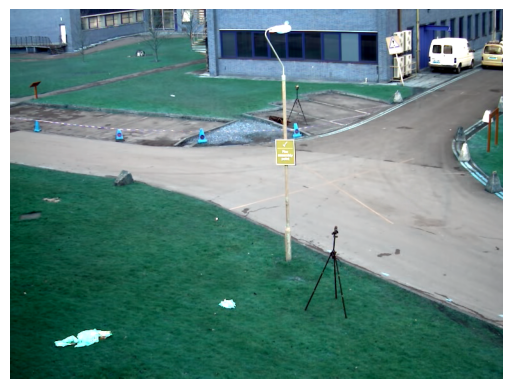

In [103]:
frame_median=np.median(frames,axis=0).astype(dtype=np.uint8)
plt.imshow(frame_median)
plt.axis('off')
plt.show()

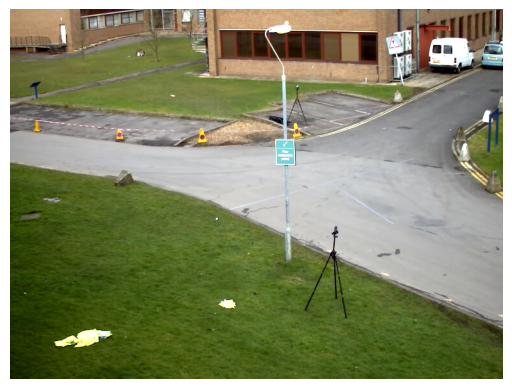

In [104]:
frame_median=np.median(frames,axis=0).astype(dtype=np.uint8)
plt.imshow(convert_to_rgb(frame_median))
plt.axis('off')
plt.show()

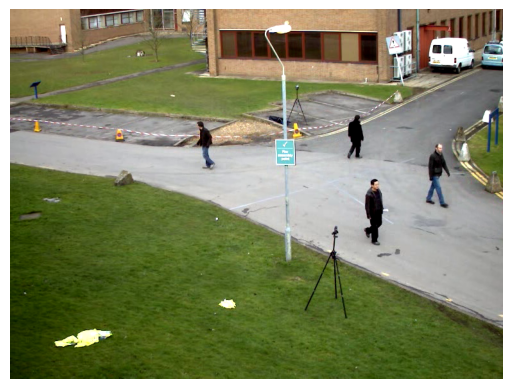

In [105]:
frame=frames[10]
plt.imshow(convert_to_rgb(frame))
plt.axis('off')
plt.show()

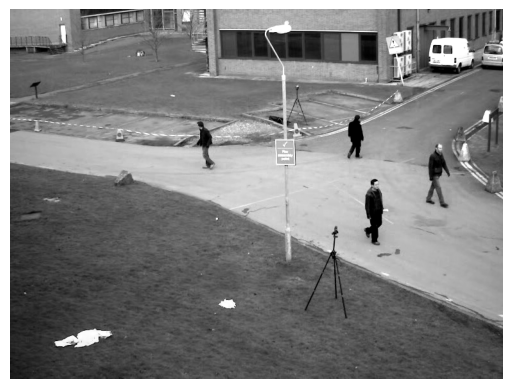

In [106]:
gray_frame=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
plt.imshow(gray_frame, cmap='gray')
plt.axis('off')
plt.show()

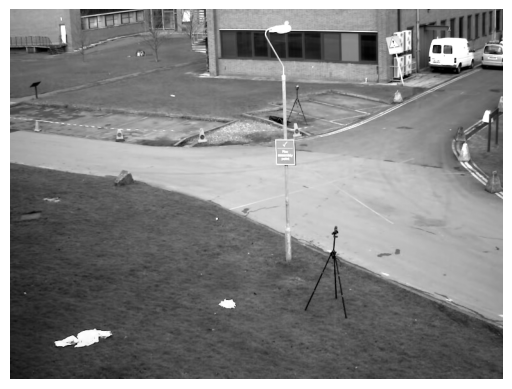

In [107]:
gray_back=cv2.cvtColor(frame_median,cv2.COLOR_BGR2GRAY)
plt.imshow(gray_back, cmap='gray')
plt.axis('off')
plt.show()

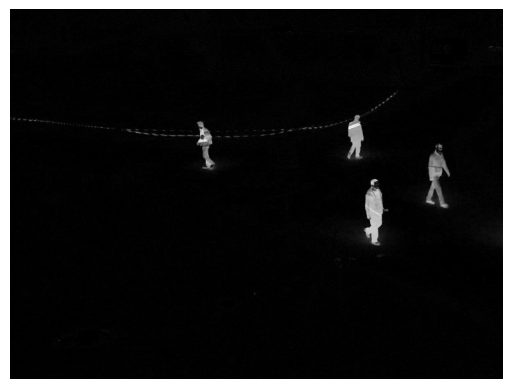

In [108]:
background_remove=cv2.absdiff(gray_back,gray_frame)
plt.imshow(background_remove, cmap='gray')
plt.axis('off')
plt.show()

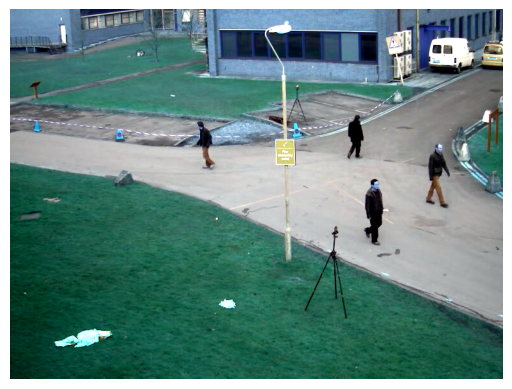

In [109]:
frame_blur=cv2.GaussianBlur(background_remove, (5,5),0,background_remove)
plt.imshow(frame, cmap='gray')
plt.axis('off')
plt.show()

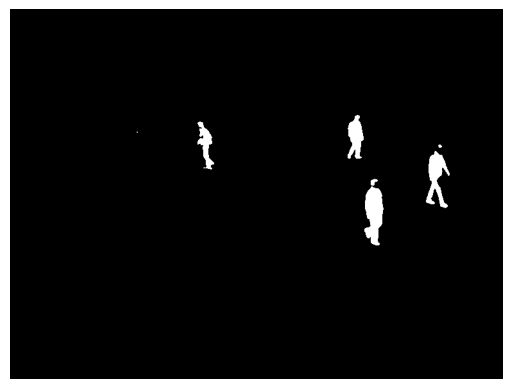

In [110]:
ret,frame_trs=cv2.threshold(frame_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(convert_to_rgb(frame_trs))
plt.axis('off')
plt.show()

In [111]:
(countours,_)=cv2.findContours(frame_trs, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


In [112]:
countours

(array([[[563, 276]],
 
        [[562, 277]],
 
        [[562, 278]],
 
        [[557, 283]],
 
        [[557, 284]],
 
        [[556, 285]],
 
        [[556, 286]],
 
        [[555, 287]],
 
        [[555, 288]],
 
        [[554, 289]],
 
        [[554, 297]],
 
        [[553, 298]],
 
        [[553, 311]],
 
        [[554, 312]],
 
        [[554, 314]],
 
        [[555, 315]],
 
        [[555, 320]],
 
        [[556, 321]],
 
        [[556, 324]],
 
        [[557, 325]],
 
        [[557, 326]],
 
        [[559, 326]],
 
        [[560, 327]],
 
        [[560, 330]],
 
        [[561, 331]],
 
        [[561, 335]],
 
        [[562, 336]],
 
        [[561, 337]],
 
        [[561, 338]],
 
        [[560, 339]],
 
        [[559, 339]],
 
        [[558, 340]],
 
        [[555, 340]],
 
        [[554, 341]],
 
        [[553, 341]],
 
        [[552, 342]],
 
        [[552, 346]],
 
        [[554, 348]],
 
        [[554, 351]],
 
        [[555, 352]],
 
        [[555, 354]],
 
        [[557, 3

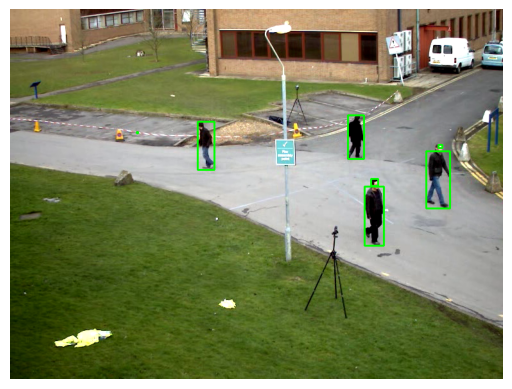

In [113]:
for i in countours:
    x,y,w,h=cv2.boundingRect(i)
    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
plt.imshow(convert_to_rgb(frame))
plt.axis('off')
plt.show()

In [ ]:
## in one cell 
import cv2

captures = cv2.VideoCapture("vtest.avi")

back_subtractor = cv2.createBackgroundSubtractorMOG2()

fps = captures.get(cv2.CAP_PROP_FPS)
width = int(captures.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(captures.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"avc1")

writer = cv2.VideoWriter(
    "tracked_example.mp4",
    fourcc,
    fps,
    (width, height)
)

while captures.isOpened():
    ret, frame = captures.read()

    if not ret:
        break

    mask = back_subtractor.apply(frame)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:
        if cv2.contourArea(contour) > 500:
            x, y, w, h = cv2.boundingRect(contour)

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

    writer.write(frame)

    cv2.imshow("Original Feed", frame)
    cv2.imshow("FG Mask", mask)

    if cv2.waitKey(30) & 0xFF == 27:
        break

captures.release()
writer.release()
cv2.destroyAllWindows()

print("Video saved successfully as tracked_example.mp4")


Video saved successfully as tracked_example.mp4
